In [10]:
import numpy as np
import matplotlib.pyplot as plt
from bandit import BanditSigmoid, BanditLinear, BanditCongestion
from reinforcement_learning import (
    streaming_cross_learning,
    streaming_maynard_cross_learning,
    parallel_cross_learning,
    parallel_maynard_cross_learning,
)
from analytical_solutions import replicator_dynamic
import matplotlib.gridspec as gridspec

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

plt.rcParams["text.latex.preamble"] = r"\usepackage{lmodern} \usepackage{amsmath}"
# Options
params = {
    "text.usetex": True,
    "font.size": 15,
    "font.family": "lmodern",
    #   'text.latex.unicode': True,
}
plt.rcParams.update(params)

# Streaming  RL plots


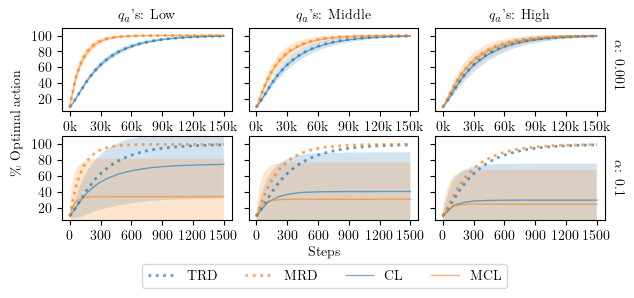

In [7]:
alphas = [0.001, 0.1]

names = ["near zero", "evenly spaced", "near one"]
names_dict = {
    names[0]: "Low",
    names[1]: "Middle",
    names[2]: "High",
}
alpha_dict = {
    alphas[0]: "Small",
    alphas[1]: "Large",
}
steps_dict = {
    names[0]: {alphas[0]: 150000, alphas[1]: 1500},
    names[1]: {alphas[0]: 150000, alphas[1]: 1500},
    names[2]: {alphas[0]: 150000, alphas[1]: 1500},
}

seeds = 1000
alpha_baseline = 0.01
fontsize = 10

# plot stuff
plt.rcParams.update({"font.size": fontsize})
colors = ["#1f77b4", "#00008b", "#ff7f0e", "#ff4b33"]

# create 6 subplots top for small alphas and down for large alphas

fig = plt.figure(figsize=(7, 2.5))  # or use tight_layout() later
outer = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.1)
fig.text(
    0.06,
    0.5,
    r"$\%$ Optimal action",
    horizontalalignment="center",
    verticalalignment="center",
    rotation="vertical",
    fontsize=fontsize,
)
fig.text(
    0.92,
    0.73,
    r"$\alpha$: " + f"{alphas[0]}",
    horizontalalignment="center",
    verticalalignment="center",
    rotation=270,
    fontsize=fontsize,
)
fig.text(
    0.92,
    0.28,
    r"$\alpha$: " + f"{alphas[1]}",
    horizontalalignment="center",
    verticalalignment="center",
    rotation=270,
    fontsize=fontsize,
)
fig.text(
    0.5,
    -0.02,
    "Steps",
    horizontalalignment="center",
    verticalalignment="center",
    fontsize=fontsize,
)

axs = []
for i, name in enumerate(names):
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[i], height_ratios=[1, 1], hspace=0.3
    )
    steps = steps_dict[name]
    if i == 0:
        ax0 = fig.add_subplot(inner[0])
        ax1 = fig.add_subplot(inner[1], sharey=ax0)

        ax0.set_yticks(np.arange(20, 120, 20))
        ax0.set_yticklabels([f"{i:.0f}" for i in np.arange(20, 120, 20)])
        ax0.set_ylim(5, 110)

    else:
        ax0 = fig.add_subplot(inner[0], sharey=axs[0])
        ax1 = fig.add_subplot(inner[1], sharey=axs[0])

        ax0.tick_params(labelleft=False)
        ax1.tick_params(labelleft=False)

    ax0.set_xticks(
        np.arange(
            0,
            steps[alphas[0]] + int(steps[alphas[0]] / 5),
            int(steps[alphas[0]] / 5),
        )
    )
    ax0.set_xticklabels(
        [
            f"{i/1000:.0f}k"
            for i in np.arange(
                0,
                steps[alphas[0]] + int(steps[alphas[0]] / 5),
                int(steps[alphas[0]] / 5),
            )
        ]
    )

    ax1.set_xticks(
        np.arange(
            0,
            steps[alphas[1]] + int(steps[alphas[1]] / 5),
            int(steps[alphas[1]] / 5),
        )
    )
    ax1.set_xticklabels(
        [
            f"{i:.0f}"
            for i in np.arange(
                0,
                steps[alphas[1]] + int(steps[alphas[1]] / 5),
                int(steps[alphas[1]] / 5),
            )
        ]
    )

    ax0.set_title(r"$q_a$'s: " + f"{names_dict[names[i]]}", fontsize=fontsize)

    axs.append(ax0)
    axs.append(ax1)


for i, ax in enumerate(axs):
    if i % 2 == 0:
        j = 0
        name = names[int(i / 2)]
        bandit = BanditLinear(name=names[int(i / 2)])
        alpha = alphas[0]
        step = steps_dict[name][alpha]

    else:
        j = 1
        alpha = alphas[1]
        step = steps_dict[name][alpha]

    _, optimal_action_trd = replicator_dynamic(
        delta=alpha, bandit=bandit, steps=step, trd=True
    )

    _, optimal_action_mrd = replicator_dynamic(
        delta=alpha, bandit=bandit, steps=step, trd=False
    )

    _, optimal_action_cl = streaming_cross_learning(
        steps=step, seeds=seeds, alpha=alpha, bandit=bandit
    )

    optimal_action_cl = optimal_action_cl.numpy()

    ax.plot(
        range(step),
        optimal_action_trd * 100,
        label="TRD",
        color=colors[0],
        linestyle="dotted",
        linewidth=2,
        alpha=0.7,
    )

    del optimal_action_trd

    ax.plot(
        range(step),
        optimal_action_mrd * 100,
        label="MRD",
        color=colors[2],
        linestyle="dotted",
        linewidth=2,
        alpha=0.7,
    )

    del optimal_action_mrd

    ax.plot(
        range(step),
        optimal_action_cl.mean(axis=1) * 100,
        label=r"CL",
        color=colors[0],
        linewidth=1,
        alpha=0.6,
    )

    ax.fill_between(
        range(step),
        optimal_action_cl.mean(axis=1) * 100 - optimal_action_cl.std(axis=1) * 100,
        optimal_action_cl.mean(axis=1) * 100 + optimal_action_cl.std(axis=1) * 100,
        facecolor=colors[0],
        alpha=0.2,
    )

    del optimal_action_cl

    _, optimal_action_mcl = streaming_maynard_cross_learning(
        steps=step,
        seeds=seeds,
        alpha=alpha,
        alpha_baseline=alpha_baseline,
        bandit=bandit,
    )

    optimal_action_mcl = optimal_action_mcl.numpy()

    ax.plot(
        range(step),
        optimal_action_mcl.mean(axis=1) * 100,
        label=r"MCL",
        color=colors[2],
        linewidth=1,
        alpha=0.6,
    )

    ax.fill_between(
        range(step),
        optimal_action_mcl.mean(axis=1) * 100 - optimal_action_mcl.std(axis=1) * 100,
        optimal_action_mcl.mean(axis=1) * 100 + optimal_action_mcl.std(axis=1) * 100,
        facecolor=colors[2],
        alpha=0.2,
    )

    del optimal_action_mcl


lines_labels = [axs[0].get_legend_handles_labels(), axs[1].get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
unique = dict(zip(labels, lines))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=4,
    fontsize=fontsize,
)


plt.savefig(f"streaming_rl_experiments.pdf", bbox_inches="tight", dpi=900)

# Parallel RL plots


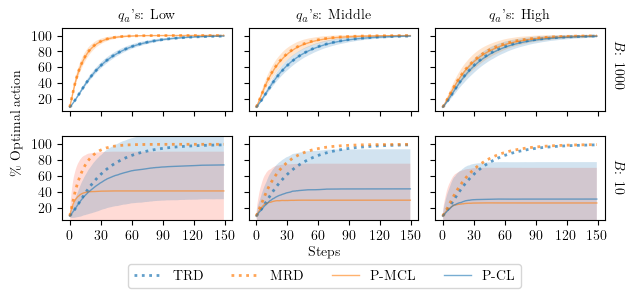

In [8]:
parallel_envs = [1000, 10]
names = ["near zero", "evenly spaced", "near one"]
names_dict = {
    names[0]: "Low",
    names[1]: "Middle",
    names[2]: "High",
}
parallel_envs_dict = {
    parallel_envs[0]: "Small",
    parallel_envs[1]: "Large",
}
steps_dict = {names[0]: 150, names[1]: 150, names[2]: 150}

seeds = 1000
fontsize = 10

# plot stuff
plt.rcParams.update({"font.size": fontsize})
colors = ["#1f77b4", "#00008b", "#ff7f0e", "#ff4b33"]


fig = plt.figure(figsize=(7, 2.5))  # or use tight_layout() later
outer = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.1)
fig.text(
    0.06,
    0.5,
    r"$\%$ Optimal action",
    horizontalalignment="center",
    verticalalignment="center",
    rotation="vertical",
    fontsize=fontsize,
)
fig.text(
    0.92,
    0.73,
    r"$B$: " + f"{parallel_envs[0]}",
    horizontalalignment="center",
    verticalalignment="center",
    rotation=270,
    fontsize=fontsize,
)
fig.text(
    0.92,
    0.28,
    r"$B$: " + f"{parallel_envs[1]}",
    horizontalalignment="center",
    verticalalignment="center",
    rotation=270,
    fontsize=fontsize,
)
fig.text(
    0.5,
    -0.02,
    "Steps",
    horizontalalignment="center",
    verticalalignment="center",
    fontsize=fontsize,
)

axs = []
for i, name in enumerate(names):
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[i], height_ratios=[1, 1], hspace=0.3
    )
    step = steps_dict[name]
    steps_increment = int(step / 5)
    if i == 0:
        ax0 = fig.add_subplot(inner[0])
        ax1 = fig.add_subplot(inner[1], sharey=ax0, sharex=ax0)

        ax0.set_yticks(np.arange(20, 120, 20))
        ax0.set_yticklabels([f"{i:.0f}" for i in np.arange(20, 120, 20)])
        ax0.set_ylim(5, 110)

        ax0.set_xticks(np.arange(0, step + steps_increment, steps_increment))
        ax0.set_xticklabels(
            [f"{i:.0f}" for i in np.arange(0, step + steps_increment, steps_increment)]
        )
        ax0.tick_params(labelbottom=False)

    else:
        ax0 = fig.add_subplot(inner[0], sharey=axs[0])
        ax1 = fig.add_subplot(inner[1], sharex=ax0, sharey=axs[0])
        ax0.set_xticks(np.arange(0, step + steps_increment, steps_increment))
        ax0.set_xticklabels(
            [f"{i:.0f}" for i in np.arange(0, step + steps_increment, steps_increment)]
        )
        ax0.tick_params(labelleft=False, labelbottom=False)
        ax1.tick_params(labelleft=False)

    ax0.set_title(r"$q_a$'s: " + f"{names_dict[names[i]]}", fontsize=fontsize)

    axs.append(ax0)
    axs.append(ax1)

for i, ax in enumerate(axs):

    if i % 2 == 0:
        j = 0
        name = names[int(i / 2)]
        bandit = BanditLinear(name=name)
        parallel_env = parallel_envs[0]
    else:
        j = 1
        parallel_env = parallel_envs[1]

    step = steps_dict[name]

    mean_rewards_trd, optimal_action_trd = replicator_dynamic(
        delta=1, bandit=bandit, steps=step, trd=True
    )

    mean_rewards_mrd, optimal_action_mrd = replicator_dynamic(
        delta=1, bandit=bandit, steps=step, trd=False
    )

    mean_rewards_pcl, optimal_action_pcl = parallel_cross_learning(
        steps=step, seeds=seeds, bandit=bandit, parallel_envs=parallel_env
    )

    mean_rewards_pmcl, optimal_action_pmcl = parallel_maynard_cross_learning(
        steps=step,
        seeds=seeds,
        bandit=bandit,
        parallel_envs=parallel_env,
    )

    ax.plot(
        range(step),
        optimal_action_trd * 100,
        label=r"TRD",
        color=colors[0],
        linestyle="dotted",
        linewidth=2,
        alpha=0.7,
    )
    ax.plot(
        range(step),
        optimal_action_mrd * 100,
        label=r"MRD",
        color=colors[2],
        linestyle="dotted",
        linewidth=2,
        alpha=0.7,
    )

    ax.plot(
        range(step),
        optimal_action_pmcl.mean(axis=1) * 100,
        label=r"P-MCL",
        color=colors[2],
        linewidth=1,
        alpha=0.6,
    )

    ax.fill_between(
        range(step),
        optimal_action_pmcl.mean(axis=1) * 100 - optimal_action_pmcl.std(axis=1) * 100,
        optimal_action_pmcl.mean(axis=1) * 100 + optimal_action_pmcl.std(axis=1) * 100,
        facecolor=colors[2 + j],
        alpha=0.2,
    )

    ax.plot(
        range(step),
        optimal_action_pcl.mean(axis=1) * 100,
        label=r"P-CL",
        color=colors[0],
        linewidth=1,
        alpha=0.6,
    )

    ax.fill_between(
        range(step),
        optimal_action_pcl.mean(axis=1) * 100 - optimal_action_pcl.std(axis=1) * 100,
        optimal_action_pcl.mean(axis=1) * 100 + optimal_action_pcl.std(axis=1) * 100,
        facecolor=colors[0],
        alpha=0.2,
    )


lines_labels = [axs[0].get_legend_handles_labels(), axs[1].get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
unique = dict(zip(labels, lines))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=4,
    fontsize=fontsize,
)


plt.savefig(f"parallel_rl_experiments.pdf", bbox_inches="tight", dpi=900)

# Congestion plots

In [ ]:
import ipywidgets as widgets

banditcongestion = BanditCongestion(
    q_star=[0.5, 0.5], gap=0.1, congestion_factors=[0.1, 0.4], device="cpu"
)


def plot_rewards(p=0.5):
    policy_vector = np.array([p, 1 - p])
    actions = np.random.choice(
        banditcongestion.return_no_actions(), size=1000, p=policy_vector
    )

    rewards = banditcongestion.pull(actions, policy_vector)

    rewards_action_0 = rewards[actions == 0]
    rewards_action_1 = rewards[actions == 1]

    fig, ax = plt.subplots(1, 2)
    ax[0].hist(rewards_action_0, bins=20)
    ax[1].hist(rewards_action_1, bins=20)
    ax[0].set_xlim(0, 1)
    ax[1].set_xlim(0, 1)
    ax[0].set_title(f"Action 0 (p={p:.2f})")
    ax[1].set_title(f"Action 1 (p={1-p:.2f})")
    plt.tight_layout()
    plt.show()


slider = widgets.FloatSlider(
    value=0.5,
    min=0.0,
    max=1.0,
    step=0.01,
    description="p (action 0):",
    style={"description_width": "initial"},
)
widgets.interact(plot_rewards, p=slider)

interactive(children=(FloatSlider(value=0.5, description='p (action 0):', max=1.0, step=0.01, style=SliderStyl…

<function __main__.plot_rewards(p=0.5)>

<>:82: SyntaxWarning: invalid escape sequence '\%'
<>:82: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_38392/1005702671.py:82: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("\% on site A")


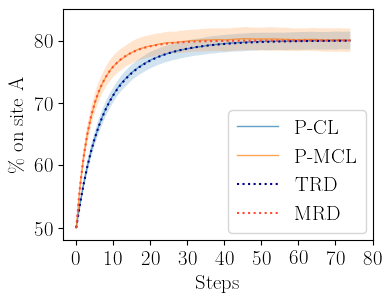

In [12]:
steps = 75
seeds = 1000
parallel_envs = 2000
congestion_factors = [0.1, 0.4]
q_star = [0.7, 0.7]

colors = ["#1f77b4", "#00008b", "#ff7f0e", "#ff4b33"]
banditcongestion = BanditCongestion(
    q_star=[0.7, 0.7], gap=0.1, congestion_factors=congestion_factors, device="cpu"
)


_, policy_cl = parallel_cross_learning(
    steps=steps, seeds=1000, bandit=banditcongestion, parallel_envs=2000
)

other_policy_cl = 1 - policy_cl

_, policy_rd = replicator_dynamic(
    delta=1, bandit=banditcongestion, steps=steps, trd=True
)

_, policy_mcl = parallel_maynard_cross_learning(
    steps=steps, seeds=1000, bandit=banditcongestion, parallel_envs=2000
)

other_policy_mcl = 1 - policy_mcl

_, policy_mrd = replicator_dynamic(
    delta=1, bandit=banditcongestion, steps=steps, trd=False
)


fig, ax = plt.subplots(1, 1, figsize=(4, 3))

policy_cl = policy_cl * 100
policy_mcl = policy_mcl * 100
policy_rd = policy_rd * 100
policy_mrd = policy_mrd * 100

ax.plot(
    range(steps),
    policy_cl.mean(axis=1),
    label="P-CL",
    linewidth=1,
    alpha=0.7,
    color=colors[0],
)

ax.plot(
    range(steps),
    policy_mcl.mean(axis=1),
    label="P-MCL",
    linewidth=1,
    alpha=0.7,
    color=colors[2],
)

ax.fill_between(
    range(steps),
    policy_cl.mean(axis=1) - policy_cl.std(axis=1),
    policy_cl.mean(axis=1) + policy_cl.std(axis=1),
    alpha=0.2,
)

ax.fill_between(
    range(steps),
    policy_mcl.mean(axis=1) - policy_mcl.std(axis=1),
    policy_mcl.mean(axis=1) + policy_mcl.std(axis=1),
    alpha=0.2,
)

# ax.fill_between(
#     range(steps),
#     other_policy_cl.mean(axis=1) - other_policy_cl.std(axis=1),
#     other_policy_cl.mean(axis=1) + other_policy_cl.std(axis=1),
#     alpha=0.2,
# )

ax.plot(range(steps), policy_rd, label="TRD", linestyle="dotted", color=colors[1])
ax.plot(range(steps), policy_mrd, label="MRD", linestyle="dotted", color=colors[3])
ax.set_ylabel("\% on site A")
ax.set_xlabel("Steps")
ax.set_xticks(range(0, steps + 10, 10))
ax.set_ylim(48, 85)
# ax.set_title(r"{$\omega$}" f"= {congestion_factors[0], congestion_factors[1]}")
fig.legend(loc="lower right", bbox_to_anchor=(0.91, 0.10))
plt.savefig(f"congestion_experiment_rl.pdf", bbox_inches="tight", dpi=900)
# plt.show()
# ax.plot(range(steps), 1 - policy_rd, label="TRD", linestyle="dotted")